![tutorial banner](https://github.com/PV-Tutorials/2025_pvlib_pvps_task13/blob/main/static/pvlib_pvps_logo.png?raw=true)


# Workshop on Bifacial Tracking Systems

This material will be used during the Bifacial Tracking Systems Workshop organized by the IEA PVPS Task 13 in Rome, Italy on February 27th, 2025. The workshop will give an introduction to how to model single-axis tracking (SAT) with bifacial photovoltaic (PV) modules

In the tutorial we will be simulating a real Italian SAT system with the following specifications:
* 550 W Bifacial  Mono PERC modules JAM72D30 ([link to datasheet](https://www.jasolar.com/uploadfile/2021/0706/20210706053456650.pdf))
* Number of modules: 5859* Modules per string: 27
* Configuration: Single-axis trackers – 1P
* Inverters: 
14 string inverters( 215 kW eac)h* g
Pi:tch 4.r* Notes: es
No ground work was done to increase alb– 1P


## Step 0: Familiarize yourself with Google Colab

The notebook can be seamlessly run in Google Colab, a free no-installation tool for running Python code from your web browser. 

Notebooks are organized by text and code "cells".  You can double-click a cell to start editing it.  To render a text cell, or execute a code cell, hit shift+enter.

In the code cell below, try out some math calculations to explore how the notebook and Python works:

In [1]:
# write some code and execute it here
a = 1
b = 2
print(a*b)

2


## Step 1: Install pvlib

First, we need to get pvlib installed in the Colab environment.  Active the following code cell (left click) and execute it (shift+enter) to automatically download and install pvlib:

In [2]:
!pip install pvlib==0.11.2

## Step 2: Use pvlib

Here's a simple example of running pvlib code: using pvlib and pandas (a library for data analysis), calculate a clear-sky irradiance profile for Rome for today (August 22).

In [30]:
import pvlib
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
site_location = pvlib.location.Location(latitude=41.890, longitude=12.492)

times = pd.date_range(start='2025-02-27 00:00', end='2025-02-27 23:59', freq='5min', tz='Europe/Rome')

clearsky_irradiance = site_location.get_clearsky(times)

<Axes: title={'center': 'Clear-Sky Simulation'}, ylabel='Irradiance [W/m2]'>

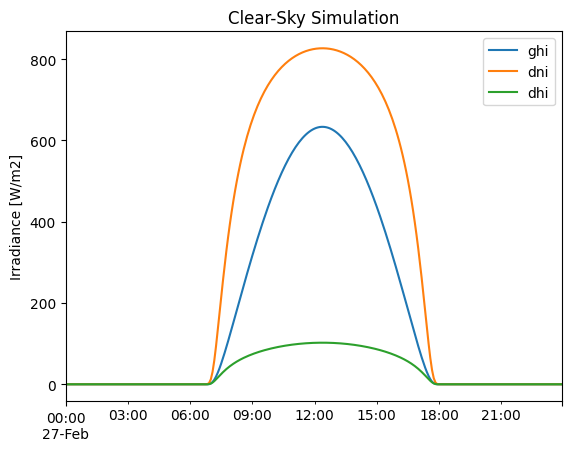

In [14]:
clearsky_irradiance.plot(ylabel='Irradiance [W/m2]', title='Clear-Sky Simulation')

If you want to look up how to use a function, you can either look up its page in the pvlib documentation (https://pvlib-python.readthedocs.io/en/stable/reference/index.html).

## Step 3: Irradiance data
Now, let's get serious and get some actual irradiance data. For this purpose, we will use pvlib's iotools module. You can read about the type of weather data supported [here](https://pvlib-python.readthedocs.io/en/stable/user_guide/weather_data.html).

In this tutorial, we will retrieve TMY irradiance data from PVGIS. The relevant pvlib function is [pvlib.iotools.get_pvgis_tmy](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.iotools.get_pvgis_tmy.html).

Can you figure out how to download data for Rome? Note, the data is labeled by the left edge (start of interval).

In [44]:
# Write your code here to retrieve irradiance data
data, months, inputs, meta = pvlib.iotools.get_pvgis_tmy(
    latitude=41.890,
    longitude=12.492,
)

data.index = data.index + pd.Timedelta(minutes=30)

data

,temp_air,relative_humidity,ghi,dni,dhi,IR(h),wind_speed,wind_direction,pressure
time(UTC),,,,,,,,,
2019-01-01 00:30:00+00:00,6.56,67.23,0.0,0.0,0.0,254.95,3.95,352.0,100843.0
2019-01-01 01:30:00+00:00,6.28,67.58,0.0,0.0,0.0,253.71,3.99,351.0,100843.0
2019-01-01 02:30:00+00:00,5.99,67.93,0.0,0.0,0.0,252.47,4.04,351.0,100833.0
2019-01-01 03:30:00+00:00,5.71,68.28,0.0,0.0,0.0,251.23,4.09,352.0,100803.0
2019-01-01 04:30:00+00:00,5.42,68.63,0.0,0.0,0.0,250.00,4.14,351.0,100763.0
...,...,...,...,...,...,...,...,...,...
2018-12-31 19:30:00+00:00,7.98,65.47,0.0,0.0,0.0,261.15,3.71,1.0,100723.0
2018-12-31 20:30:00+00:00,7.69,65.82,0.0,0.0,0.0,259.91,3.75,1.0,100733.0
2018-12-31 21:30:00+00:00,7.41,66.17,0.0,0.0,0.0,258.67,3.80,2.0,100773.0


## Step 4: Calculate solar position

When using irradiance data, we almost always need to know the solar position for each time step.

Can you figure out how to calculate the solar position for the time steps of the time series downloaded in the previous step?

*Hint: the time steps are the index of the DataFrame from the previous step, use DataFrame.index.*

In [26]:
# Write your code here to calculate solar position
solar_position = site_location.get_solarposition(data.index)

solar_position

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
time(UTC),,,,,,
2018-12-31 23:30:00+00:00,160.828620,160.828620,-70.828620,-70.828620,11.827138,-3.185965
2019-01-01 00:30:00+00:00,155.270778,155.270778,-65.270778,-65.270778,46.306460,-3.205782
2019-01-01 01:30:00+00:00,145.892492,145.892492,-55.892492,-55.892492,67.230746,-3.225590
2019-01-01 02:30:00+00:00,135.160134,135.160134,-45.160134,-45.160134,80.989160,-3.245391
2019-01-01 03:30:00+00:00,124.032840,124.032840,-34.032840,-34.032840,91.625437,-3.265183
...,...,...,...,...,...,...
2018-12-31 18:30:00+00:00,119.144533,119.144533,-29.144533,-29.144533,264.131142,-3.086760
2018-12-31 19:30:00+00:00,130.289455,130.289455,-40.289455,-40.289455,274.055665,-3.106617
2018-12-31 20:30:00+00:00,141.266099,141.266099,-51.266099,-51.266099,286.115706,-3.126466


## Step 5: Calculate tracker orientations

TODO - write some text

In [54]:
max_tracker_angle = 60  # [degrees]
pitch = 4.5  # [m] center-to-center tracker spacing in the horizontal dimension
module_length = 2.285  # [m] from datasheet
gcr = module_length / pitch  # [-] ground cover ratio
height = 2.5  # (assumed)
albedo = 0.2

# calculate tracker rotations for a single-axis tracker
tracker_orientations = pvlib.tracking.singleaxis(
    apparent_zenith=solar_position['apparent_zenith'],
    apparent_azimuth=solar_position['azimuth'],
    axis_tilt=0,  # flat terrain
    axis_azimuth=0,  # north-south
    max_angle=max_tracker_angle,
    backtrack=True,
    gcr=gcr,
)

tracker_orientations.dropna()

,tracker_theta,aoi,surface_azimuth,surface_tilt
time(UTC),,,,
2019-01-01 07:30:00+00:00,9.333907,75.669114,90.000000,9.333907
2019-01-01 08:30:00+00:00,27.727046,59.426023,90.000000,27.727046
2019-01-01 09:30:00+00:00,48.396985,57.543544,90.000000,48.396985
2019-01-01 10:30:00+00:00,22.793718,63.415341,90.000000,22.793718
2019-01-01 11:30:00+00:00,-8.914220,64.642476,270.000003,8.914220
...,...,...,...,...
2018-12-31 11:30:00+00:00,-9.189149,64.707644,270.000000,9.189149
2018-12-31 12:30:00+00:00,-38.188990,60.630470,270.000000,38.188990
2018-12-31 13:30:00+00:00,-59.465102,53.065447,270.000000,59.465102


## Step 6: Calculate plane of array irradiance
The irradiance data we obtained from PVGIS contains the three standard components:
- global horizontal irradiance (GHI)
- diffuse horizontal irradiance (DHI)
- direct normal irradiance (DNI)

However, to determine PV generation, we need to know the incident irradiance on the PV cells which is the plane of array (POA) irradiance. Additionally, since we are working with bifacial irradiance, we also need to estimate the rear-side irradiance.

To do this, we will be using pvlib's [infinite sheds model](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.bifacial.infinite_sheds.get_irradiance.html) which is based on view factors and assumes the PV system comprises parallel, evenly spaced rows on a level, horizontal surface.

Can you use the infite sheds model to calculate front and rear side irradiance? Remember you have determined the trakcer orientation in the previous step.

In [62]:
# Write your code here to calculate plane of array irradiance
bifaciality = 0.7  # from datasheet (bifaciality: 70%+/-10%)

dni_extra = pvlib.irradiance.get_extra_radiation(data.index)

front_rear_irradiance = pvlib.bifacial.infinite_sheds.get_irradiance(
    surface_tilt=tracker_orientations['surface_tilt'],
    surface_azimuth=tracker_orientations['surface_azimuth'],
    solar_zenith=solar_position['apparent_zenith'],
    solar_azimuth=solar_position['azimuth'],
    gcr=gcr,
    height=height,
    pitch=pitch,
    ghi=data['ghi'],
    dhi=data['dhi'],
    dni=data['dni'],
    albedo=albedo,
    model='haydavies',
    dni_extra=dni_extra,
    bifaciality=bifaciality,
)

front_rear_irradiance.dropna()

,poa_front,poa_front_direct,poa_front_diffuse,poa_front_ground_diffuse,poa_front_sky_diffuse,shaded_fraction_front,poa_back,poa_back_direct,poa_back_diffuse,poa_back_ground_diffuse,poa_back_sky_diffuse,shaded_fraction_back,poa_global
time(UTC),,,,,,,,,,,,,
2019-01-01 07:30:00+00:00,23.692052,0.000000,23.692052,0.010477,23.681575,0.000000e+00,2.457526,0.0,2.457526,2.351995,0.105531,0.0,25.377914
2019-01-01 08:30:00+00:00,389.595251,360.579562,29.015689,0.131029,28.884660,2.220446e-16,4.284398,0.0,4.284398,3.039015,1.245382,0.0,392.534347
2019-01-01 09:30:00+00:00,479.388246,450.429048,28.959198,2.003557,26.955642,0.000000e+00,16.923039,0.0,16.923039,12.655581,4.267457,0.0,490.997451
2019-01-01 10:30:00+00:00,440.296969,406.134509,34.162460,0.949160,33.213300,0.000000e+00,34.587242,0.0,34.587242,33.650411,0.936831,0.0,464.023817
2019-01-01 11:30:00+00:00,432.660426,396.686309,35.974117,0.167540,35.806577,0.000000e+00,41.412733,0.0,41.412733,41.267357,0.145376,0.0,461.069561
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 11:30:00+00:00,412.375059,355.909082,56.465977,0.169813,56.296164,0.000000e+00,39.577589,0.0,39.577589,39.334535,0.243054,0.0,439.525285
2018-12-31 12:30:00+00:00,469.770728,432.068814,37.701913,2.157349,35.544565,0.000000e+00,27.393496,0.0,27.393496,24.228552,3.164945,0.0,488.562666
2018-12-31 13:30:00+00:00,486.726662,448.312004,38.414659,1.197536,37.217123,0.000000e+00,14.528974,0.0,14.528974,4.400234,10.128740,0.0,496.693539


# Step 7: Calculate module temperature

The power efficiency of a PV module depends on its temperature (roughly, a 0.4% decrease for every increase in degree C).  Module temperature can be estimated based on ambient temperature and POA irradiance.

pvlib includes several models for estimating module temperature. Can you find one in the documentation?

In [66]:
# Write your code here to calculate module temperature using a model of your choosing
module_temperature = pvlib.temperature.faiman(
    poa_global=front_rear_irradiance['poa_global'],
    temp_air=data['temp_air'],
    # default values
    wind_speed=1.0,
    u0=25.0,
    u1=6.84)

module_temperature.dropna()

time(UTC)
2019-01-01 07:30:00+00:00     5.367045
2019-01-01 08:30:00+00:00    18.138340
2019-01-01 09:30:00+00:00    22.740774
2019-01-01 10:30:00+00:00    23.243612
2019-01-01 11:30:00+00:00    24.130828
                               ...    
2018-12-31 11:30:00+00:00    24.724186
2018-12-31 12:30:00+00:00    27.004305
2018-12-31 13:30:00+00:00    27.769671
2018-12-31 14:30:00+00:00    21.606787
2018-12-31 15:30:00+00:00    13.323962
Length: 4440, dtype: float64

# Step 7: Calculate PV power

With the plane of array irradiance and module temperature ready, we can now estimate the PV output power.  There are several modeling approaches available here, including:

* Simple efficiency (like in PVWatts v5)
* Single-diode models, like in PVsyst and SAM
* Empirical methods like the SAPM

Each type of these PV models requires different types of parameters.  They all produce estimates of the maximum power point (Pmp), while the fancier ones also estimate other quantities like open circuit voltage and short circuit current.

The simplest option is to use [pvlib.pvsystem.pvwatts_dc](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.pvsystem.pvwatts_dc.html).  Can you use it with the POA irradiance and module temperature to estimate the output power for a 300 W module with a temperature coefficient of -0.004?

<Axes: >

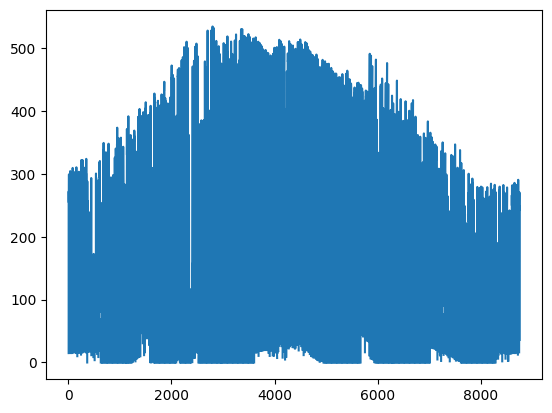

In [67]:
# Write your code here to calculate PV power
dc_power = pvlib.pvsystem.pvwatts_dc(
    g_poa_effective=front_rear_irradiance['poa_global'],
    # simplified assumptions that module and cell temperature are the same
    temp_cell=module_temperature,
    pdc0=550,
    gamma_pdc=-0.0035,  # from datasheet
    temp_ref=25.0,
)

dc_power.reset_index(drop=True).plot()

[![Creative Commons License](https://i.creativecommons.org/l/by/4.0/88x31.png)](http://creativecommons.org/licenses/by/4.0/)

This work is licensed under a [Creative Commons Attribution 4.0 International License](http://creativecommons.org/licenses/by/4.0/).